# Taller de Clasificación y Regresión

Elaborado por:
    
Luis Octavio González Salcedo

Diplomado en Inteligencia Artificial y Aprendizaje Profundo.



## 1. Importación de Índices



Los índices pertinentes que se deben tener son:

**NumPy**: Corresponde a una biblioteca para el lenguaje de programación Python que da soporte para crear vectores y matrices grandes multidimensionales, junto con una gran colección de funciones matemáticas de alto nivel para operar con ella. [[1]](https://es.wikipedia.org/wiki/NumPy)

**Pandas**: Corresponde a una herramienta de manipulación y análisis de datos de código abierto rápida, potente, flexible y fácil de usar, construida sobre el lenguaje de programación Python. [[2]](https://es.wikipedia.org/wiki/Pandas_(software))

**Seaborn**: Corresponde a una biblioteca de datos de Python basada en matplotlib, y proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. [[3]](https://seaborn.pydata.org/)

**Matplotlib**: Corresponde a una biblioteca completa para crear visualizaciones estáticas, animadas e interactivas en Python. [[4]](https://es.wikipedia.org/wiki/Matplotlib)

**TensorFlow**: Librería Python para computación numérica rápida.  También es una librería que puede utilizarse para crear modelos de Deep Learning directamente o utilizando librerías de envolturas que simplifican el proceso construido sobre TensorFlow. [[5]](https://es.wikipedia.org/wiki/TensorFlow)

**Pathlib**: Es un módulo que ofrece clases que representan rutas del sistema de archivos con semántica apropiada para diferentes sistemas operativos. Las clases de ruta se dividen entre rutas puras , que proporcionan operaciones puramente computacionales sin Entradas / Salidas, y rutas concretas, que heredan de rutas puras pero también proporcionan operaciones de Entrada / Salida. Crea una instancia de una ruta concreta para la plataforma en la que se ejecuta el código. Los caminos puros son útiles en algunos casos especiales; por ejemplo: 1.- Si desea manipular las rutas de Windows en una máquina Unix (o viceversa). No puede crear una instancia de un WindowsPathcuando se ejecuta en Unix, pero puede crear una instancia PureWindowsPath; 2.- Desea asegurarse de que su código solo manipule rutas sin acceder al sistema operativo. En este caso, la instanciación de una de las clases puras puede ser útil, ya que simplemente no tienen operaciones de acceso al sistema operativo. [[6]](https://docs.python.org/3/library/pathlib.html).

**Os**: Este módulo os proporciona un contenedor para módulos específicos de la plataforma, tales como posix, nt y mac. La interfaz de programación para las funciones disponibles en todas las plataformas debe ser la misma, por lo que usar el módulo os ofrece cierta medida de portabilidad. Sin embargo, no todas las funciones están disponibles en todas las plataformas. Muchas de las funciones de gestión de procesos descritas no están disponibles para Windows. [[7]](https://rico-schmidt.name/pymotw-3/os/).


In [1]:

import tensorflow as tf ##importación de tensorflow

import pathlib ##importación del módulo pathlib
import os ##importación del módulo os
import matplotlib.pyplot as plt ##importación de matplotlib
import pandas as pd ##importación de pandas
import numpy as np ##importación de numpy

##configura las opciones de impresión
##Estas opciones determinan la forma en que se muestran los números de punto flotante, las matrices y otros objetos NumPy.
##En este caso, usa el parámetro de precisión, que corresponde al número de dígitos de precisión para salida de punto flotante.
np.set_printoptions(precision=4)


## 2. Red Neuronal de Clasificación Binaria para Predecir el Cáncer de Seno


### 2.1 Conjunto de Datos



La base de datos tomada para el taller corresponde a la almacenada en el archivo data_cancer_BCW.csv, la cual es descrita en [[8]](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data) Este conjunto de datos contiene características que se calculan a partir de una imagen digitalizada de una aspiración con aguja fina (FNA) de una masa mamaria, de tal manera que se describen las características de los núcleos celulares presentes en la imagen. En la imagen n es el espacio tridimensional descrito por [K. P. Bennett y O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34], como se muestra en [[9]](http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.23.3307&rep=rep1&type=pdf). Esta base de datos también se encuentra disponible en el servidor ftp de UW CS: ftp ftp.cs.wisc.edu, cd math-prog/cpo-dataset/machine-learn/WDBC/; aunque se menciona en la referencia 8, que también se puede encontrar en el Repositorio de aprendizaje automático de la UCI [[10]](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29), no hay a la fecha del reporte, enlace disponible. 

El conjunto de datos contiene valores para las siguientes variables, que se describen a continuación:



Se calculan diez características de valor real para cada núcleo celular:

a) Radius, corresponde al radio, el cual se mide promediando la longitud de los segmentos lineales radiales definidos por el centroide y los puntos del perímetro (es decir la media de las distancias desde el centro hasta los puntos del perímetro).

b) Texture, corresponde a la textura del núcleo celular que se mide al encontrar la varianza de las intensidades de escala de grises en los pixeles en el perímetro (desviación estándar de los valores de la escala de grises).

c) Perimeter, corresponde al perímetro nuclear que es la distancia total entre dos puntos.
d) Area, corresponde al área nuclear que se mide contando el número de pixeles en el interior entre dos puntos y agregando la mitad de los pixeles en el perímetro.
e) Smoothness, que corresponde a la suavidad o lisura del contorno nuclear (variación local en longitudes de radio).

f) Compactness, que corresponde a la compacidad, donde el perímetro y el área se combinan para obtener una medida de espacio compacto de los núcleos celulares (perímetro^2/área - 1.0).

g) Concavity, corresponde a la concavidad (severidad de las porciones cóncavas del contorno)

h) Concave Points, que corresponde a los puntos cóncavos (número de porciones cóncavas del contorno)

i) Symmetry, corresponde a la simetría

j) Fractal Dimension, corresponde a la dimensión fractal de una célula y se calcula utilizando el método de la Paradoja  de  la  línea  de  costa de Benoît Mandel-brot ("aproximación de la línea de costa" - 1).

La media, el error estándar y "peor" o mayor (media de los tres valores más grandes) de estas características se calcularon para cada imagen, resultando en 30 funciones. Por ejemplo, el campo 3 es Radio medio, campo 13 es Radio SE, el campo 23 es Peor radio.

Todos los valores de las funciones se recodifican con cuatro dígitos significativos.

Faltante de valores de atributo: ninguno

Distribución de clases: 357 benignas, 212 malignas


In [2]:

from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing


In [3]:

os.getcwd() ##Se visualiza donde está ubicado el directorio de trabajo


'C:\\Users\\Usuario\\Desktop\\luis octavio gonzalez\\Curso DIplomado IA & AP\\Repositorio Curso\\Diplomado\\Temas\\Fundamentos\\Cuadernos'

In [4]:

##Se carga el conjunto de datos en la variable C
C = 'data_cancer_BCW.csv'
data1 = pd.read_csv(C)
print(data1.shape)
data1.head(10)


(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750



### 2.2 Antecedentes de estudios relacionados



De acuerdo con [Jorge Armando Millán Gómez y Jaime Brandon Robles Fajardo; (2020). Modelo en Machine Learning para el Diagnóstico del Cáncer de Mama. (Trabajo Final: Especialista en Ingeniería de Software, Universidad Distrital de Colombia, Bogotá, 168p.], disponible en [[11]](https://repository.udistrital.edu.co/bitstream/handle/11349/25070/RoblesFajardoJaimeBrandon2020.pdf?sequence=1&isAllowed=y), mencionan que diversos métodos básados en Aprendizaje de Máquina se han propuesto para la predicción y diagnóstico del cáncer, como se relaciona algunos a continuación:

    Usando los datos de pronósstico de cáncer de seno de Wisconsin, y con resultados de precisión en promedio del 76 %, el articulo "A Method to Select a Good Setting for the kNN Algorithm when Using itfor Breast Cancer Prognosis" propone una aplicación del método k-Nearest Neighbours (kNN) para el pronóstico del cáncer de mama basado en las herramientas de Machine learning, en el que se selecciona la mejor configuración según los parámetros que se pueden cambiar al momento de utilizar la técnica de clasificación.
    
    Un modelo que utiliza cuatro técnicas de Machine learning, a saber Support Vector Machine, Logistic Regression, Decision Tree y k-Nearest Neighbours (kNN) en donde por medio delSLSQP se asigna un peso a cada modelo de clasificación y la predicción de cada clasificador se combina mediante la técnica de votación suave, es reportado en el artículo "An Ensemble Model for Breast Cancer Prediction Using Sequential Least Squares Programming Method (SLSQP)".
    La utilización de diferentes algoritmos de clasificación de tres conjuntos de datos de enfermedades, entre ellas el cancer de seno, fue desarrollada mediante el modelado blackward con prueba del valor-p, como se reporta en el artículo "Application  of  Machine  Learning  in  Disease  Prediction".
    
    Un nuevo método para dectetar cáncer de seno con alta precisión, método que consta de dos partes donde se preparan las imágenes de mamografía para el proceso de extracción de características, lo cual se hace con redes supervisadas con una red de backpropagation y con un modelo de regresión logística, como lo reporta el artículo "Breast  Cancer  Detection  using  K-nearest  Neighbor  Machine  Learning Algorithm".

La revisión de estado del arte realizada por Millán y Robles (2020), discuten alrededor de una decena más de trabajos relacionados con el uso de técnicas de Aprendizaje de Máquina en la predicción y diagnóstico de cáncer, lo cual muestra además de su desempeño en el acierto, que estas técnicas constituyen un campo fértil para estos desarrollos así como una propuesta de una agenda futura.



### 2.3 Limpieza de datos 



Formateo de datos:


In [5]:
##Eliminar la primera fila
##Eliminación de la cabecera
data1_1 = data1.dropna(axis=1)

##Tipo de datos:
data1_1.dtypes()


TypeError: 'Series' object is not callable


Comprobación de datos faltantes:


In [6]:

##Contando los datos vacios (NaN, NAN, na)
data1.isna().sum()


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


### 2.4 Procesamiento de los datos de datos



En el conjunto de datos se encuentran registros de personas con tumores diagnosticados como Benignos y otros como Malignos, B y M respectivamente, y cuya información es utilizada para el entrenamiento y prueba del modelo:



System:
    python: 3.8.5 (default, Sep  3 2020, 21:29:08) [MSC v.1916 64 bit (AMD64)]
executable: C:\Users\Usuario\anaconda3\python.exe
   machine: Windows-10-10.0.19041-SP0

Python dependencies:
          pip: 21.0.1
   setuptools: 52.0.0.post20210125
      sklearn: 0.24.2
        numpy: 1.20.1
        scipy: 1.6.2
       Cython: 0.29.23
       pandas: 1.2.4
   matplotlib: 3.3.4
       joblib: 1.0.1
threadpoolctl: 2.1.0

Built with OpenMP: True


C:\Users\Usuario\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


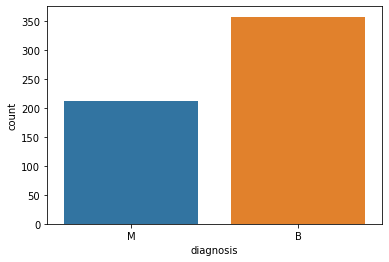

In [7]:

##Importaciones Adicionales:
import seaborn as sns ##Importar librería para la visualización de datos estadisticos
import sklearn
sklearn.show_versions()
import sklearn.preprocessing ##Importar librería para pre-procesar datos

##Agrupar los valores de la columna indicada y sumarlos:
data1['diagnosis'].value_counts()

##Visualización de la columna "diagnosis":
sns_plot = sns.countplot(data1['diagnosis'],label="Count")



Usando un gráfico un gráfico de correlación cruzada entre todas las variables que es denominado de parejas o pairplot(). Esto es importante para entender las relaciones que existen entre el conjunto de variables y sus respectivo diagnóstico, y de esta manera se establecen cuáles son las variables que tienen mayor influencia en el entrenamiento del sistema:


In [ ]:

##Visualización gráfico de correlación cruzada:
sns_plot = sns.pairplot(data1, hue="diagnosis", height=2.5)



Una manera de evidenciar la relación porcentual que existe entre cada variable y que muestra de una forma muy concisa y útil las relaciones entre todas las magnitudes de interés de este conjunto de datos, es usando un grafico de calor:


In [ ]:

##Visualización gráfico de calor:
plt.figure(figsize=(20,20))
sns.plot = sns.heatmap(data1.corr(), annot=True, fmt='.0%')



Los atributos que contiene el conjunto de datos en sus totalidad son del tipo float y corresponden a las características de las imágenes digitalizadas de los núcleos celulares, para el caso del id del registro es del tipo int, y la diagnosis que es de tipo string son los que tienen tipo de dato diferente. Para entrenar los modelos se requieren que los datos pasen por un pre-procesamiento que convierte los datos en valores enteros. Para este caso, la columna diagnosis pasará de tener las letras M y B a los números 1 y 0, respectivamente. Para ello se utiliza la función LabelEncoder de la librería preprocesing de sklearn:


In [8]:

##Importación de LabelEncoder()
from sklearn.preprocessing import LabelEncoder

##Conversión de los valores "B" y "M" en valores enteros 0 y 1:
labelencoder_Y = LabelEncoder()
data1.iloc[:,1] = labelencoder_Y.fit_transform(data1.iloc[:,1].values)
print(labelencoder_Y.fit_transform(data1.iloc[:,1].values))


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 1
 0 1 0 1 1 0 0 0 1 1 0 1 1 1 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1
 0 1 0 0 0 1 0 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0
 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0
 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1
 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 0
 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 1 0 1 0 0 1 


### 2.5 Aplicación de modelos de Maching Learning



Los modelos de Machine Learning utilizados para el diagnostico de cáncer de mama son del tipo Aprendizaje Supervisado (*Supervised Learning*). En este tipo de aprendizaje se realiza  un entrenamiento de un modelo de tal manera que se tiene un conocimiento  previo  de  cuáles  deberían  ser  los  valores  de  salida  para  las muestras. Por lo tanto, su objetivo es aprender una función que, dada una muestra de datos y resultados deseados, se aproxime mejor a la relación entre entrada y salida observable en los datos.

Para implementar esta técnica se utiliza la librería creada por Google para el lenguaje de programación Python llamada Scikit learn la cual contiene un conjunto de funciones para aplicar las técnicas de Machine Learning. Para efectos de este taller y de mostrar el funcionamiento de los Modelos de Machine Learning aplicados al diagnostico de cáncer de mama se va a realizar una prueba con variables de dos pacientes. Los modelos utilizados para el diagnóstico de cáncer de mama son: Logistic  Regression, Decision Trees, Gaussian Naive Bayes, K-Nearest Neighbors (KNN), Random Forest, Support Vector Machines(SVM).

Los pacientes seleccionados son el paciente 1 cuyo ID es 8110824, identificado como paciente con diagnóstico benigno. Mientras que el paciente 2 cuyo ID es 84358402 está identificado como paciente con diagnóstico maligno. Los pacientes están en las filas 21 y 4 respectivamente, y para efecto de pruebas no se toma la última columna.


In [9]:

##paciente 1  id= 8510824   diagnosis= B:
paciente_1 = data1.iloc[21, 2:31].values
##Visualizar las variables del paciente 1:
print("datos paciente 1 : \n", paciente_1)

##paciente 2  id= 84358402   diagnosis= M:
paciente_2 = data1.iloc[4, 2:31].values
##Visualizar las variables del paciente 2:
print("datos paciente 2 : \n", paciente_2)


datos paciente 1 : 
 [9.504e+00 1.244e+01 6.034e+01 2.739e+02 1.024e-01 6.492e-02 2.956e-02
 2.076e-02 1.815e-01 6.905e-02 2.773e-01 9.768e-01 1.909e+00 1.570e+01
 9.606e-03 1.432e-02 1.985e-02 1.421e-02 2.027e-02 2.968e-03 1.023e+01
 1.566e+01 6.513e+01 3.149e+02 1.324e-01 1.148e-01 8.867e-02 6.227e-02
 2.450e-01]
datos paciente 2 : 
 [2.029e+01 1.434e+01 1.351e+02 1.297e+03 1.003e-01 1.328e-01 1.980e-01
 1.043e-01 1.809e-01 5.883e-02 7.572e-01 7.813e-01 5.438e+00 9.444e+01
 1.149e-02 2.461e-02 5.688e-02 1.885e-02 1.756e-02 5.115e-03 2.254e+01
 1.667e+01 1.522e+02 1.575e+03 1.374e-01 2.050e-01 4.000e-01 1.625e-01
 2.364e-01]



Una vez se conoce el valor de la columna diagnosis del conjunto de pacientes en el conjunto de datos, esta es transformada en valores enteros para que los modelos procesen la informaciónn de forma eficiente. Para este caso la columna de diagnosis pasa a tener las letras M y B a los números 1 y 0 respectivamente. Se asignan los datos de la columna 2 a la columna 31 en la variable X y los datos de la columna 1 (diagnosis) en la variable Y. Luego se utiliza la función train_test_split de la librería model_selection de sklearn para asignar el 75 % de los datos para que los modelos aprendan y el 25 % para comprobar la efectividad de los mismos:


In [10]:

from sklearn.preprocessing import LabelEncoder
labelencoder_Y = LabelEncoder()
data1.iloc[:,1]= labelencoder_Y.fit_transform(data1.iloc[:,1].values)

##datos del conjunto de datos:
X = data1.iloc[:, 2:31].values
##label "diagnosis"
Y = data1.iloc[:, 1].values

##Importar libreria para la separación de los datos de entrenamiento:
from sklearn.model_selection import train_test_split
##Utilizar 25% de los Datos para Entrenar los Modelos:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size =0.25, random_state = 0)



#### 2.5.1. Modelo Logistic Regression (Regresión Logística)



El Modelo de Regrerión Logística es un modelo lineal para la clasificación, cuya técnica se ajusta a un modelo lineal con coeficientes definidos para minimizar la suma residual de cuadrados entre los objetivos observados en un conjunto de datos y los objetivos predichos por la aproximación lineal [[12]](https://es.wikipedia.org/wiki/Regresi%C3%B3n_log%C3%ADstica). En este modelo, las probabilidades que describen los posibles resultados se modelan utilizando la función LogisticRegression de la librería model_selection de sklearn [[13]](https://realpython.com/logistic-regression-python/).

Para realizar el diagnóstico de cancer de mama en los pacientes seleccionados 1 y 2 (es decir, la predicción en estos dos pacientes), se debe hacer el entrenamiento del modelo con las variables X_train y Y_train:


In [11]:

##Importación de librería para usar el Modelo Logistic Regression:
from sklearn.linear_model import LogisticRegression

##Uso del Modelo Logistic Regression:
logisticregression = LogisticRegression(random_state = 0)

##Entrenamiento del Modelo Logistic Regression:
logisticregression.fit(X_train, Y_train)

##Impresión de la respuesta del Modelo Logistic Regression:
print('Logistic Regression Training Accuracy: ', logisticregression.score(X_train, Y_train))


Logistic Regression Training Accuracy:  0.960093896713615


C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



El entrenamiento del Modelo Logistic Regression muestra una precisión en el entrenamiento del 96.01% (Accuracy = 0.9601)



Con el modelo entrenado, se procede a aplicarlo sobre los pacientes seleccionados (pacientes 1 y 2):


In [12]:

prediction_1 = logisticregression.predict([paciente_1])
prediction_prob_1 = logisticregression.predict_proba([paciente_1])
print("Diagnosis: ", prediction_1)
print("Probabilidad Benigno: ", prediction_prob_1[0][0])
print("Probabilidad Maligno: ", prediction_prob_1[0][1])


Diagnosis:  [0]
Probabilidad Benigno:  0.9997527111750901
Probabilidad Maligno:  0.00024728882490987285


In [13]:

prediction_2 = logisticregression.predict([paciente_2])
prediction_prob_2 = logisticregression.predict_proba([paciente_2])
print("Diagnosis: ", prediction_2)
print("Probabilidad Benigno: ", prediction_prob_2[0][0])
print("Probabilidad Maligno: ", prediction_prob_2[0][1])


Diagnosis:  [1]
Probabilidad Benigno:  2.8190857305210315e-06
Probabilidad Maligno:  0.9999971809142695



#### 2.5.2 Modelo Decision Tress (Árbol de Decisión)



Los árboles de decisión tienen como objetivo crear modelos que predicen el valor de una variable mediante el aprendizaje de reglas de decisión simples las cuales se infieren a partir de las características de los datos [[14]](https://es.wikipedia.org/wiki/Aprendizaje_basado_en_%C3%A1rboles_de_decisi%C3%B3n). En este modelo, las probabilidades que describen los posibles resultados se modelan utilizando la función DecisionTreeClassifier de la librería tree de sklearn [[15]](https://www.datacamp.com/community/tutorials/decision-tree-classification-python).

Para realizar el diagnóstico de cancer de mama en los pacientes seleccionados 1 y 2 (es decir, la predicción en estos dos pacientes), se debe hacer el entrenamiento del modelo con las variables X_train y Y_train:


In [14]:

##Importación de librería para uso del modelo Decision Tree:
from sklearn.tree import DecisionTreeClassifier

##Uso del modelo Decision Tree:
desiciontreemodel = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)

##Entrenamiento del Modelo Desicion Tree:
desiciontreemodel.fit(X_train, Y_train)

##Impresión de la respuesta del Modelo Decision Tree:
print('Decision Tree Classifier Accuracy:', desiciontreemodel.score(X_train, Y_train))


Decision Tree Classifier Accuracy: 1.0



El entrenamiento del Modelo Decision Tree muestra una precisión en el entrenamiento del 100.00% (Accuracy = 1.0000)



Con el modelo entrenado, se procede a aplicarlo sobre los pacientes seleccionados (pacientes 1 y 2):


In [15]:

prediction_1 = desiciontreemodel.predict([paciente_1])
prediction_prob_1 = desiciontreemodel.predict_proba([paciente_1])
print("Diagnosis: ", prediction_1)
print("Probabilidad Benigno: ", prediction_prob_1[0][0])
print("Probabilidad Maligno: ", prediction_prob_1[0][1])


Diagnosis:  [0]
Probabilidad Benigno:  1.0
Probabilidad Maligno:  0.0


In [16]:

prediction_2 = desiciontreemodel.predict([paciente_2])
prediction_prob_2 = desiciontreemodel.predict_proba([paciente_2])
print("Diagnosis: ", prediction_2)
print("Probabilidad Benigno: ", prediction_prob_2[0][0])
print("Probabilidad Maligno: ", prediction_prob_2[0][1])


Diagnosis:  [1]
Probabilidad Benigno:  0.0
Probabilidad Maligno:  1.0



#### 2.5.3. Modelo Random Forest (Clasificador Aleatorio de Bosque)



El Modelo de Clasificador Aleatorio de Bosque (también conocido como Bosques Aleatorios) corresponde a un meta-estimador que se ajusta a varios clasificadores de árbol de decisión en varias submuestras de un conjunto de datos que utiliza el promedio para mejorar la predicción (precisión y control del sobreajuste) [[16]](https://es.wikipedia.org/wiki/Random_forest).

Para el uso de este modelo clasificador, las probabilidades que describen los posibles resultados se modelan utilizando la función RandomForestClassifier de la librería ensemble de sklearn [[17]](https://inteligencia-analitica.com/random-forest-python/).

Para realizar el diagnóstico de cancer de mama del paciente 1 y paciente 2 se debe entrenar el modelo con las variables X_train y Y_train:


In [17]:

##Importación de la librería para usar el Modelo RandomForestClassifier:
from sklearn.ensemble import RandomForestClassifier

##Uso del Modelo RandomForestClassifier:
ArbolAleatorio = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)

##Entrenamiento del Modelo RandomForestClassifier:
ArbolAleatorio.fit(X_train, Y_train)

##Impresión de la respuesta del Modelo RandomForestClassifier:
print('RandomForestClassifier Training Accuracy:', ArbolAleatorio.score(X_train, Y_train))


RandomForestClassifier Training Accuracy: 0.9953051643192489



El entrenamiento del Modelo RandomForestClassifier muestra un precisión en el entrenamiento del 99.53% (Accuracy = 0.9953).

Con el modelo entrenado se procede a aplicarlo en los pacientes seleccionados (paciente 1 y paciente 2):


In [19]:

pred_1 = ArbolAleatorio.predict([paciente_1])
pred_proba_1 = ArbolAleatorio.predict_proba([paciente_1])
print("Diagnosis", pred_1)
print("Probabilidad Benigno: ", pred_proba_1[0][0])
print("Probabilidad Maligno: ", pred_proba_1[0][1])


Diagnosis [0]
Probabilidad Benigno:  1.0
Probabilidad Maligno:  0.0


In [20]:

pred_2 = ArbolAleatorio.predict([paciente_2])
pred_proba_2 = ArbolAleatorio.predict_proba([paciente_2])
print("Diagnosis", pred_2)
print("Probabilidad Benigno: ", pred_proba_2[0][0])
print("Probabilidad Maligno: ", pred_proba_2[0][1])


Diagnosis [1]
Probabilidad Benigno:  0.0
Probabilidad Maligno:  1.0



#### 2.5.4. Modelo Gaussian Naive Bayes



Este Modelo denominado como Clasificador Bayesiano Ingenuo Gaussiano, es un método genérico de aprendizaje supervisado que se ha diseñado para resolver problemas de regresión y clasificación probabilistica;es un clasificador probabilístico fundamentado en el teorema de Bayes y algunas hipótesis simplificadoras adicionale y es a causa de estas simplificaciones, que se suelen resumir en la hipótesis de independencia entre las variables predictoras, que recibe el apelativo de naive, es decir, ingenuo  [[18]](https://es.wikipedia.org/wiki/Clasificador_bayesiano_ingenuo).

La predicción que de hace por el modelo es probilística, de modo que se pueden calcular intervalos de confianza conocidos y se decide en función de si se deben reajustar las predicciones sobre alguna región de interés. Las probabilidades que describen los posibles resultados se modelan usando la función GaussianNB de la librería naive_bayes de sklearn [[19]](https://jakevdp.github.io/PythonDataScienceHandbook/05.05-naive-bayes.html).

Para realizar el diagnóstico de cancer de mama se entrena el modelo con las variables X_train y Y_train:


In [21]:

##Importación de la librería para usar el Modelo Gaussian Naive Bayes:
from sklearn.naive_bayes import GaussianNB

##Uso del Modelo Gaussian Naive Bayes:
BayesianoIngenuo = GaussianNB()

##Entrenamiento del Modelo Gaussian Naive Bayes:
BayesianoIngenuo.fit(X_train, Y_train)

##Impresión de la respuesta del Modelo Gaussian Naive Bayes:
print('Guassian Naive Bayes Training Accuracy:', BayesianoIngenuo.score(X_train, Y_train))


Guassian Naive Bayes Training Accuracy: 0.9507042253521126



El entrenamiento del Modelo Gaussian Naive Bayes muestra un precisión en el entrenamiento del 95.07% (Accuracy = 0.9507).

Con el modelo entrenado se procede a aplicarlo en los pacientes seleccionados (paciente 1 y paciente 2):


In [23]:

pred_1 = BayesianoIngenuo.predict([paciente_1])
pred_proba_1 = BayesianoIngenuo.predict_proba([paciente_1])
print("Diagnosis", pred_1)
print("Probabilidad Benigno: ", pred_proba_1[0][0])
print("Probabilidad Maligno: ", pred_proba_1[0][1])


Diagnosis [0]
Probabilidad Benigno:  0.9999999999999998
Probabilidad Maligno:  2.1109106561728282e-16


In [24]:

pred_2 = BayesianoIngenuo.predict([paciente_2])
pred_proba_2 = BayesianoIngenuo.predict_proba([paciente_2])
print("Diagnosis", pred_2)
print("Probabilidad Benigno: ", pred_proba_2[0][0])
print("Probabilidad Maligno: ", pred_proba_2[0][1])


Diagnosis [1]
Probabilidad Benigno:  2.006997403407899e-61
Probabilidad Maligno:  1.0



#### 2.5.5. Modelo K-Nearest Neighbors, o Vecino Cercanos (KNN)



Este clasificador basado en el Modelo de Vecinos Cercanos, es un modelo supervisado cuya función es encontrar un número predefinido de muestras de entrenamiento en una distancia cercana a un nuevo punto y de esta manera predecir un valor a partir de ellas; generalmente se usa la distancia euclidiana estándar, y se conoce también el método como no generalizado en razón a que recuerda todos los datos de su entrenamiento [[20]](https://es.wikipedia.org/wiki/K_vecinos_m%C3%A1s_pr%C3%B3ximos).

Las probabilidades que describen los posibles resultados se modelan usando la función KNeighborsClassifier de la librería neighbors de sklearn [[21]](https://scikit-learn.org/stable/modules/neighbors.html).

Para realizar el diagnóstico de cancer de mama se entrena el modelo con las variables X_train y Y_train:


In [25]:

##Importación de la librería para usar el Modelo K-Nearest Neighbors:
from sklearn.neighbors import KNeighborsClassifier

##Uso del Modelo K-Nearest Neighbors:
VecinoCercano = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)

##Entrenamiento del Modelo K-Nearest Neighbors:
VecinoCercano.fit(X_train, Y_train)

##Impresión de la respuesta del Modelo K-Nearest Neighbors:
print('K-Nearest Neighbors Training Accuracy:', VecinoCercano.score(X_train, Y_train))


K-Nearest Neighbors Training Accuracy: 0.9413145539906104



El entrenamiento del Modelo K-Nearest Neighbors muestra un precisión en el entrenamiento del 94.13% (Accuracy = 0.9413).

Con el modelo entrenado se procede a aplicarlo en los pacientes seleccionados (paciente 1 y paciente 2):


In [26]:

pred_1 = VecinoCercano.predict([paciente_1])
pred_proba_1 = VecinoCercano.predict_proba([paciente_1])
print("Diagnosis", pred_1)
print("Probabilidad Benigno: ", pred_proba_1[0][0])
print("Probabilidad Maligno: ", pred_proba_1[0][1])


Diagnosis [0]
Probabilidad Benigno:  1.0
Probabilidad Maligno:  0.0


In [27]:

pred_2 = VecinoCercano.predict([paciente_2])
pred_proba_2 = VecinoCercano.predict_proba([paciente_2])
print("Diagnosis", pred_2)
print("Probabilidad Benigno: ", pred_proba_2[0][0])
print("Probabilidad Maligno: ", pred_proba_2[0][1])


Diagnosis [1]
Probabilidad Benigno:  0.0
Probabilidad Maligno:  1.0



#### 2.5.6.  Support Vector Machines SVM (Maquinas de Soporte Vecterial)



Las Máquinas de Soporte Vectorial conocidas por sus siglas en inglés SVM, son un conjunto de métodos de aprendizajes supervisado utilizados para la clasificación, regresión y detección de valores atípicos, y en la cual se utiliza un subconjunto de puntos de entrenamiento en la función de decisión los cuales son llamados vectores de soporte; de esta manera se genera una eficiencia en la memoria y el método es efectivo en casos donde el número de dimensiones es mayor que el número de muestras [[22]](https://www.cienciadedatos.net/documentos/34_maquinas_de_vector_soporte_support_vector_machines).

Las probabilidades que describen los posibles resultados se modelan utilizando la función SVC de la librería svm de sklearn [[23]](https://www.cienciadedatos.net/documentos/py24-svm-python.html).

Para realizar el diagnóstico de cancer de mama se entrena el modelo con las variables X_train y Y_train:


In [28]:

##Importación de la librería para usar el Modelo Support Vector Machines:
from sklearn.svm import SVC

##Uso del Modelo Support Vector Machines:
MSVectorial = SVC(kernel = 'linear', random_state = 0, probability = True)

##Entrenamiento del Modelo Support Vector Machines:
MSVectorial.fit(X_train, Y_train)

##Impresión de la respuesta del Modelo Support Vector Machines:
print('Support Vector Machines Training Accuracy:', MSVectorial.score(X_train, Y_train))


Support Vector Machines Training Accuracy: 0.9647887323943662



El entrenamiento del Modelo Support Vector Machines muestra un precisión en el entrenamiento del 96.48% (Accuracy = 0.9648).

Con el modelo entrenado se procede a aplicarlo en los pacientes seleccionados (paciente 1 y paciente 2):


In [31]:

pred_1 = MSVectorial.predict([paciente_1])
pred_proba_1 = MSVectorial.predict_proba([paciente_1])
print("Diagnosis", pred_1)
print("Probabilidad Benigno: ", pred_proba_1[0][0])
print("Probabilidad Maligno: ", pred_proba_1[0][1])


Diagnosis [0]
Probabilidad Benigno:  0.9993556291087115
Probabilidad Maligno:  0.0006443708912887387


In [32]:

pred_2 = MSVectorial.predict([paciente_2])
pred_proba_2 = MSVectorial.predict_proba([paciente_2])
print("Diagnosis", pred_2)
print("Probabilidad Benigno: ", pred_proba_2[0][0])
print("Probabilidad Maligno: ", pred_proba_2[0][1])


Diagnosis [1]
Probabilidad Benigno:  0.00416750279929862
Probabilidad Maligno:  0.9958324972007015



#### 2.5.7. Modelo de Red Neuronal de Clasificación Binaria



A continuación y usando la guía establecida en [[24]](https://unipython.com/clasificacion-binaria-de-un-sonar/), se procede a realizar el entrenamiento de una red neuronal para clasificación binaria que permita abordar el problema de diagnóstico que se ha realizado con los diferentes modelos de regresión mostrados y entrenados.

Se procede nuevamente a la importación de librerías y funciones necesarias:


In [ ]:

import tensorflow as tf ##importación de tensorflow

import pathlib ##importación del módulo pathlib
import os ##importación del módulo os
import matplotlib.pyplot as plt ##importación de matplotlib
import pandas as pd ##importación de pandas
import numpy as np ##importación de numpy

from pandas import read_csv
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing



Se inicializar un generador de números aleatorios para asegurar de que siempre se obtengan los mismos resultados al ejecutar el código, lo cual también puede ayudar en caso de que se haga una depuración:


In [ ]:

# semilla aleatoria
seed = 7
numpy.random.seed(seed)



Se procede nuevamente a la carga de la base de datos repitiendo el proceso anteriormente realizado:


In [3]:

os.getcwd() ##Se visualiza donde está ubicado el directorio de trabajo


'C:\\Users\\Usuario\\Desktop\\luis octavio gonzalez\\Curso DIplomado IA & AP\\Repositorio Curso\\Diplomado\\Temas\\Fundamentos\\Cuadernos'

In [4]:

##Se carga el conjunto de datos en la variable C
C = 'data_cancer_BCW.csv'
data1 = pd.read_csv(C)
print(data1.shape)
data1.head(10)


(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [10]:

##Eliminar la primera fila
##Eliminación de la cabecera
data1_1 = data1.dropna(axis=1)

print(data1_1.shape)
data1_1.head(10)


(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,1,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,1,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,1,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [11]:

##Importación de LabelEncoder()
from sklearn.preprocessing import LabelEncoder

##Conversión de los valores "B" y "M" en valores enteros 0 y 1:
labelencoder_Y = LabelEncoder()
data1.iloc[:,1] = labelencoder_Y.fit_transform(data1.iloc[:,1].values)
print(labelencoder_Y.fit_transform(data1.iloc[:,1].values))


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 1
 0 1 0 1 1 0 0 0 1 1 0 1 1 1 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1
 0 1 0 0 0 1 0 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0
 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0
 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1
 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 0
 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 1 0 1 0 0 1 

In [12]:

from sklearn.preprocessing import LabelEncoder
labelencoder_Y = LabelEncoder()
data1.iloc[:,1]= labelencoder_Y.fit_transform(data1.iloc[:,1].values)

##datos del conjunto de datos:
X = data1.iloc[:, 2:31].values
##label "diagnosis"
Y = data1.iloc[:, 1].values

##Importar libreria para la separación de los datos de entrenamiento:
from sklearn.model_selection import train_test_split
##Utilizar 25% de los Datos para Entrenar los Modelos:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size =0.25, random_state = seed)



Se crea el modelo de red neuronal usando Keras. Se utiliza scikit-learn para evaluar el modelo utilizando la validación cruzada de pliegues con stratied k-fold, que corresponde a una técnica de remuestreo que proporcionará una estimación del rendimiento del modelo. Para usar los modelos Keras con scikit-learn, se debe usar el envoltorio del KerasClassifier. Esta clase toma una función que crea y devuelve el modelo de red neuronal. También toma argumentos que se transmitirán a la llamada a fit() como el número de epochs y el batch_size. Se comienza definiendo la función que crea el modelo de referencia; en este caso el modelo tendrá una única conexión totalmente oculta con un número de neuronas ocultas.

Los pesos se inicializan utilizando un pequeño número aleatorio gaussianos, utilizamos la activación con el Rectier. La capa de salida contiene una sola neurona para hacer predicciones. Se utiliza la función de activación sigmoide para producir una salida de probabilidad en el rango de 0 a 1 que se puede convertir fácil y automáticamente a valores de clase nítidos. Finalmente, se usa la función de pérdida logarítmica (cruzamiento binario) durante el entrenamiento, la pérdida preferida para problemas de clasificación binaria. El modelo también utiliza la optimización eficiente de Adam para el descenso de gradiente y las métricas de precisión se recopilarán cuando se entrene el modelo:


In [15]:

##linea base del modelo:
def create_baseline():
    ##se crea el modelo
    model = Sequential()
    model.add(Dense(60, input_dim = 29, kernel_initializer='normal', activation='relu'))
    model.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))
    ##se Compila el modelo
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model



Ahora se evalua el modelo utilizando la validación cruzada estratificada en el marco de scikit-learn. Se pasa el número de número de epochs de entrenamiento al KerasClasificador, de nuevo usando valores por defecto razonables. También se desactiva la salida verbose dado que el modelo se creará 10 veces para las 10 validaciones cruzadas que se están realizando:


In [16]:

##Se evalúa el modelo de Red Neuronal de Clasificación Binaria:
estimator = KerasClassifier(build_fn = create_baseline, epochs = 100, batch_size = 5, verbose = 0)
kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = seed)
results = cross_val_score(estimator, X, Y, cv=kfold)
print("Baseline: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))


Baseline: 93.33% (2.80%)



Se observa entonces con el Modelo de Red Neuronal, una precisión del 93.33% (Accuracy = 0.9333).
